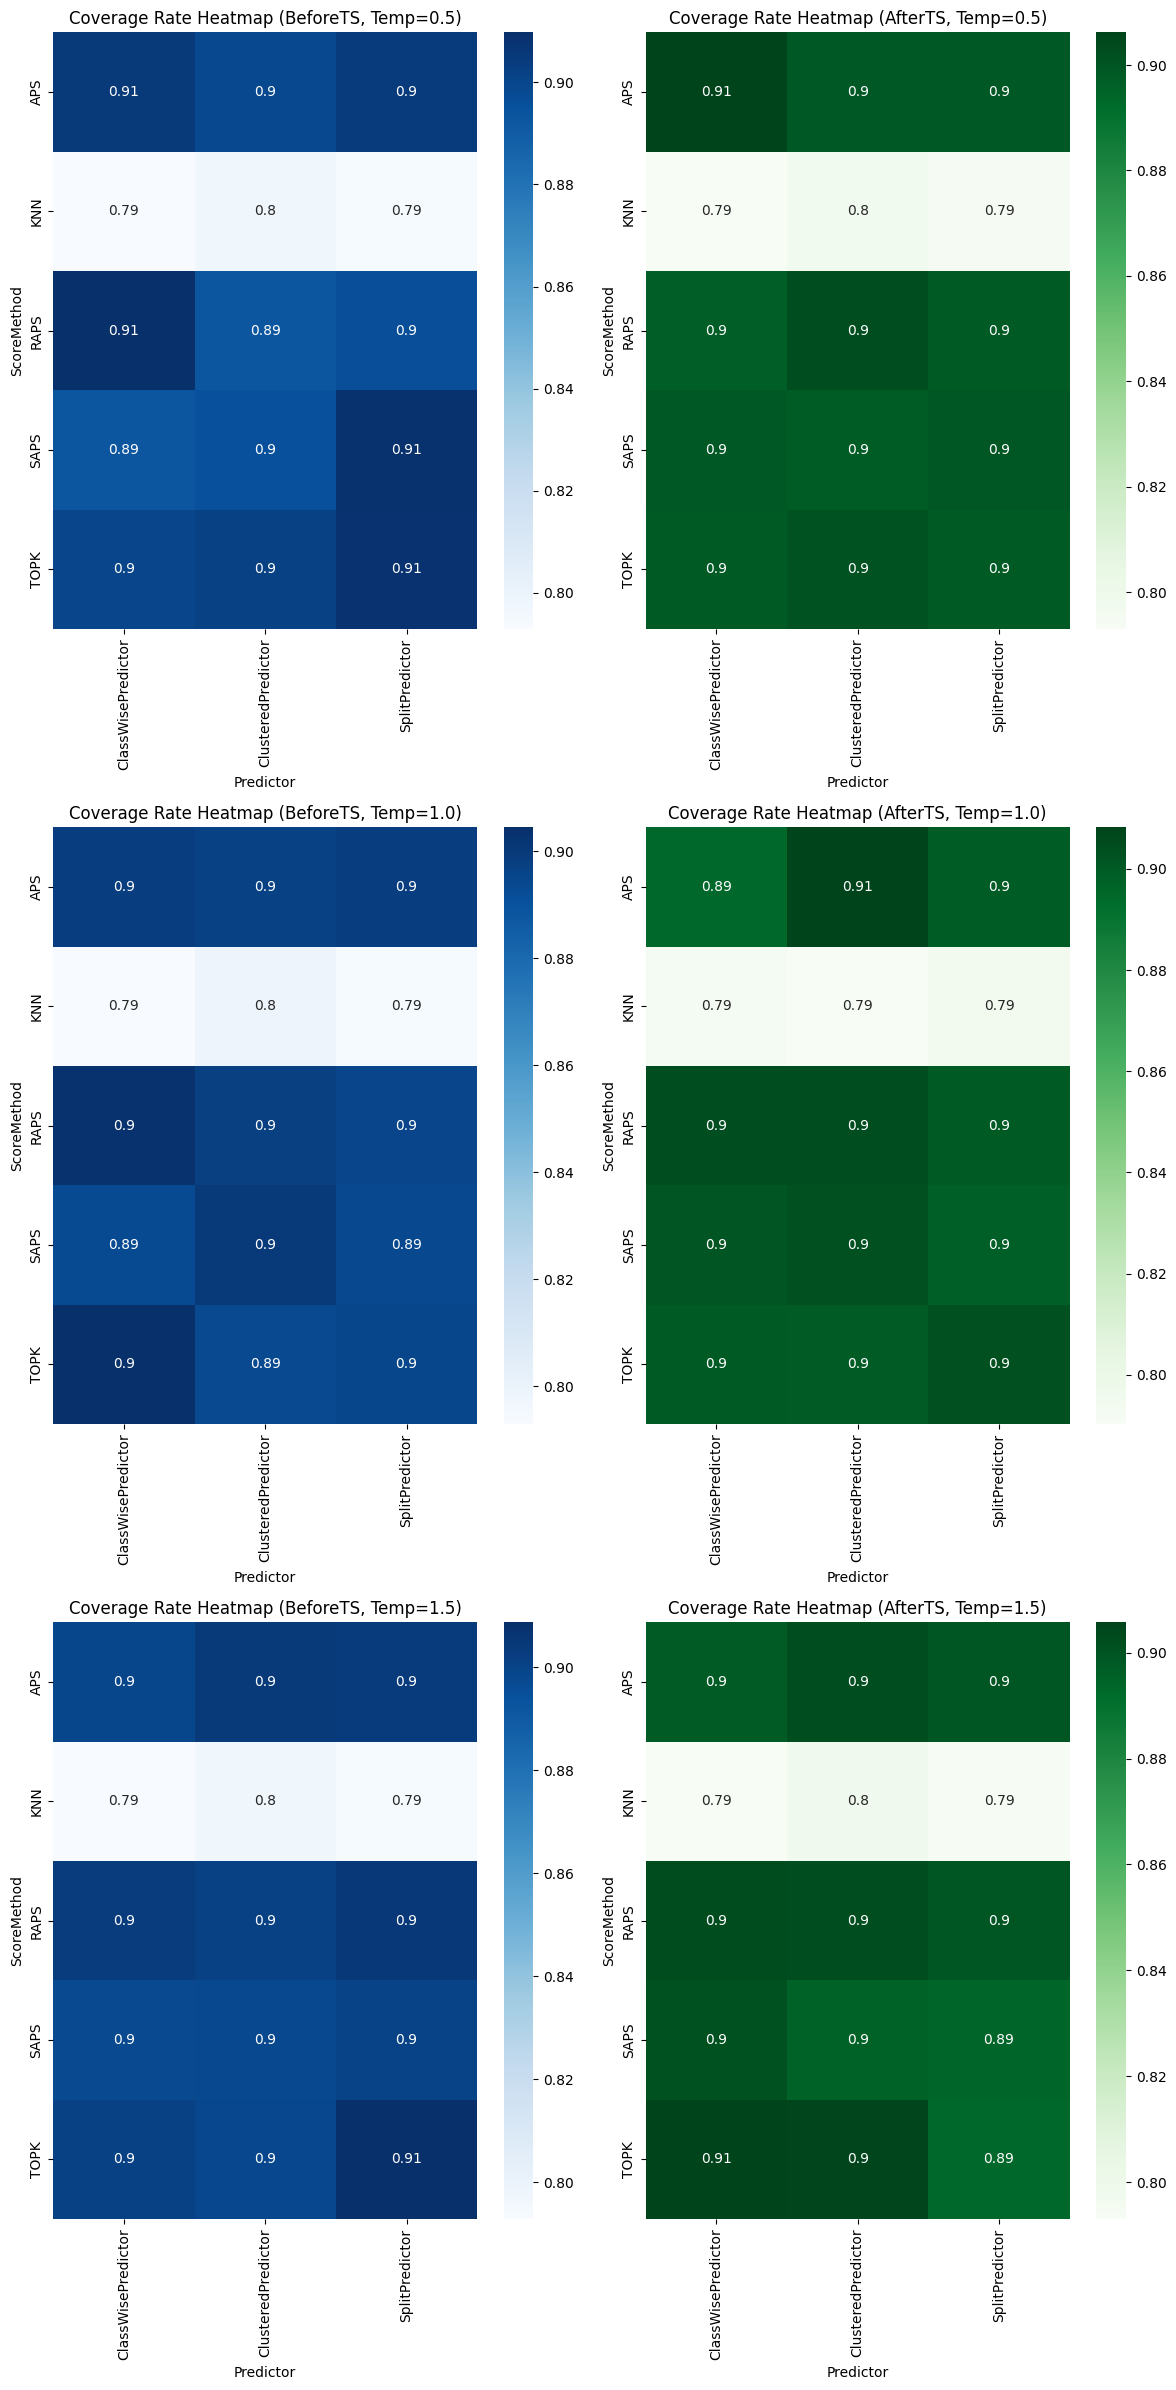

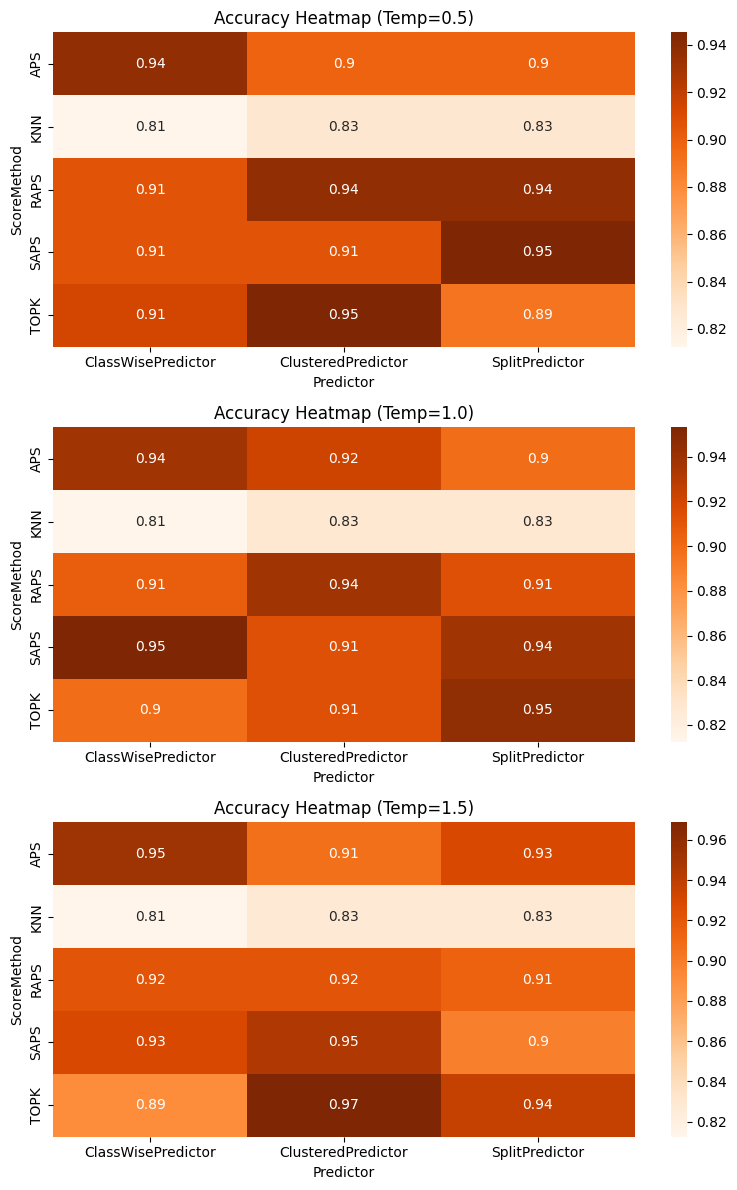

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('.')
results_df = pd.read_csv('../src/results/cp_results.csv')
temperatures = results_df["Temperature"].unique()

fig, axes = plt.subplots(len(temperatures), 2, figsize=(12, 8 * len(temperatures)))

for i, temp in enumerate(temperatures):
    df_before = results_df[(results_df["Phase"] == "BeforeTS") & (results_df["Temperature"] == temp)]
    df_after = results_df[(results_df["Phase"] == "AfterTS") & (results_df["Temperature"] == temp)]

    heatmap_before = df_before.pivot_table(index="ScoreMethod", columns="Predictor", values="CoverageRate")
    heatmap_after = df_after.pivot_table(index="ScoreMethod", columns="Predictor", values="CoverageRate")

    sns.heatmap(heatmap_before, annot=True, cmap="Blues", ax=axes[i, 0])
    axes[i, 0].set_title(f"Coverage Rate Heatmap (BeforeTS, Temp={temp})")

    sns.heatmap(heatmap_after, annot=True, cmap="Greens", ax=axes[i, 1])
    axes[i, 1].set_title(f"Coverage Rate Heatmap (AfterTS, Temp={temp})")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(temperatures), 1, figsize=(8, 4 * len(temperatures)))

for i, temp in enumerate(temperatures):
    df_accuracy = results_df[results_df["Temperature"] == temp]
    heatmap_accuracy = df_accuracy.pivot_table(index="ScoreMethod", columns="Predictor", values="Accuracy")

    sns.heatmap(heatmap_accuracy, annot=True, cmap="Oranges", ax=axes[i])
    axes[i].set_title(f"Accuracy Heatmap (Temp={temp})")

plt.tight_layout()
plt.show()

In [3]:
results_df

,Temperature,Phase,ScoreMethod,Predictor,CoverageRate,AvgSetSize,Accuracy,F1Score,Loss
0,0.5,BeforeTS,APS,SplitPredictor,0.9044,0.9177,0.859375,0.877765,0.01081
1,0.5,BeforeTS,APS,ClassWisePredictor,0.9054,0.9185,0.921875,0.928880,0.01081
2,0.5,BeforeTS,APS,ClusteredPredictor,0.8991,0.9129,0.921875,0.929558,0.01081
3,0.5,BeforeTS,RAPS,SplitPredictor,0.8964,0.9065,0.953125,0.955900,0.01081
4,0.5,BeforeTS,RAPS,ClassWisePredictor,0.9098,0.9208,0.921875,0.929037,0.01081
...,...,...,...,...,...,...,...,...,...
85,1.5,AfterTS,TOPK,ClassWisePredictor,0.9057,0.9141,0.890625,0.902722,0.00909
86,1.5,AfterTS,TOPK,ClusteredPredictor,0.9049,0.9135,0.968750,0.969513,0.00909
87,1.5,AfterTS,KNN,SplitPredictor,0.7940,0.7941,0.828125,0.851286,0.00909
88,1.5,AfterTS,KNN,ClassWisePredictor,0.7931,0.7931,0.812500,0.842738,0.00909
